---
title: "High-pressure trickle-bed hydrodynamics"
description: "Two coupled correlations — pressure gradient needing the hold-up, hold-up needing the pressure gradient — closed as a pair against the figures they were derived from, at gas densities no atmospheric study can reach."
categories: [sec:G, struct:S3, tier:T1, data:tier4, phase:gas-liquid-solid]
date: 2026-07-31
---

# High-pressure trickle-bed hydrodynamics

**Catalog ID:** `G1.7` · **Structures:** `S3` (1D steady plug-flow BVP) + algebraic
closure pair · **Tier:** T1

Industrial trickle-bed reactors hydrotreat at 20–30 MPa; until this work,
essentially every published hydrodynamic correlation had been measured at
1 bar. Wammes and Westerterp pressurised a laboratory trickle bed to 7.5 MPa,
switched between nitrogen and helium to separate pressure from gas density, and
found that **the hydrodynamics depends on the gas density and not on the
reactor pressure** — then packaged the results as two correlations that need
each other: the pressure gradient contains the liquid hold-up, and the hold-up
contains the pressure gradient.

This page closes that pair, with nothing fitted, against the two figures the
correlations describe.

## Background

In a cocurrent downflow trickle-bed reactor the liquid films over the packing
and the gas flows through the remaining voids. Two hydrodynamic quantities
carry most of the design: the **total external liquid hold-up** $\beta_t$
(liquid volume per unit void volume — residence time, wetting, and the liquid
film thickness all follow from it) and the **pressure gradient** $\Delta P/L$.

At elevated pressure the gas is no longer mechanically innocent. The pressure
gradient scales with $\rho_g u_g^2$, and once $\Delta P/(\rho_l g L)$ becomes
comparable to 1 the gas drag rivals gravity as the force driving the liquid
film — so the hold-up drops, the film thins, and the trickle-to-pulse
transition moves to higher liquid throughput. That is the physical loop the
paper's two correlations encode:

- Eq. (8): $\Delta P/L$ from a two-phase friction factor — **containing
  $\beta_t$**, because the hold-up narrows the channels the gas flows through;
- Eq. (9): the dynamic hold-up $\beta_{dyn}$ from a Reynolds–Galileo power
  product — **containing $\Delta P/(\rho_l g L)$**, because gas drag adds to
  gravity.

Neither correlation can be evaluated alone: given the operating point they form
a 2-unknown algebraic system. The paper says exactly this ("By means of Eqs
(6), (8) and (9) and the residual hold-up value, the total external liquid
hold-up and pressure drop under trickle-flow conditions can be determined") but
never shows the closed loop. Closing it is what this page adds.

The same paper measures the gas–liquid interfacial area by chemically enhanced
CO₂ absorption into amine solutions, using a plug-flow gas-phase balance —
a genuine `S3` transport model, and the part of the paper pymrm's operators can
actually discretise.

**A note on the citation.** The gallery catalogue cites this case as *Chem.
Eng. Sci.* (1991), which is the Wammes et al. CES **46** (1991) 409–417
companion on the atmospheric limit. The paper built here is the same group's
*Chemical Engineering & Technology* **14** (1991) 406–413 synthesis paper —
open access via the University of Twente repository — which itself derives
both correlations, states their fitted ranges and error statistics, and
carries the two figures used below. The CES companion is needed only for the
zero-gas-flow limit (its exponent is quoted in the CET text and checked here as
a limit, not reproduced).

## The published model

**Interfacial area by chemical absorption** (Section 2.1). For an
instantaneous-regime-free, pseudo-first-order fast reaction
($2 < Ha \ll E_{CO_2,\infty}$), the absorption flux is

$$
J_{CO_2} = m\,c_{CO_2,g}\,\sqrt{k_{1,p}\,c^p_{DEA,l}\,D_{CO_2,l}} \tag{1}
$$

and the gas phase moves in plug flow at constant velocity, so

$$
v_g\,\frac{dc_{CO_2,g}}{dx} = -J_{CO_2}\,a_{gl}. \tag{2}
$$

Integrating (2) with (1) over the bed length $L$ gives the working equation of
the measurement — interfacial area from the measured CO₂ conversion
$\xi_{CO_2}$:

$$
a_{gl} = \frac{-v_g}{m L \sqrt{k_{1,p} c^p_{DEA,l} D_{CO_2,l}}}
         \,\ln(1-\xi_{CO_2}). \tag{3}
$$

**Pressure gradient** (Section 3.3). From a force balance on the gas phase,

$$
\frac{\Delta P}{L} = f_{lg}\,\tfrac12 \rho_g u_g^2\,
\frac{1-\varepsilon}{d_p\,\varepsilon\,(1-\beta_t)}, \qquad
u_g = \frac{v_g}{\varepsilon(1-\beta_t)} \tag{5, 6}
$$

with the empirical two-phase friction factor fitted for $\beta_t > 0.25$ and
$200 < Re_g < 5000$, giving the dimensionless correlation

$$
\frac{\Delta P}{\tfrac12 \rho_g u_g^2}\left(\frac{d_p}{L}\right)
= 155 \left(\frac{\rho_g u_g \varepsilon d_p}{\eta_g (1-\varepsilon)}\right)^{-0.37}
  \left(\frac{1-\varepsilon}{\varepsilon(1-\beta_t)}\right). \tag{8}
$$

Mean relative error 12 %, standard deviation 0.14, per the paper.

*A prefactor discrepancy worth recording:* the intermediate Eq. (7) is printed
as $f_{lg} = Re_g^{-0.37}$ with **no prefactor**, with $Re_g$ on the hydraulic
diameter $\varepsilon/a_s$. Substituting that into Eq. (5) does *not* reproduce
Eq. (8) — the two printed forms differ by the factor
$155 \times 6^{-0.37} \approx 80$. Eq. (8) is self-contained, is the form the
error statistics are quoted for, and (as shown below) is the form the data
follow, so this page implements Eq. (8) and treats Eq. (7) as shorthand for
proportionality. The identity that *does* hold —
$f_{lg} = 155\,[\rho_g u_g \varepsilon d_p / (\eta_g(1-\varepsilon))]^{-0.37}$
in Eq. (5) reproducing Eq. (8) exactly — is verified numerically below.

**Liquid hold-up** (Section 3.4). The total external hold-up splits into a
residual part held at particle contact points by capillarity —
$\varepsilon\beta_r = 0.06$ for all well-wetted systems here, following Van
Swaaij's Eötvös-number relation — and a dynamic part correlated over 220
experiments:

$$
\beta_{dyn} = 3.8\,
\left(\frac{\rho_l v_l d_p}{\eta_l}\right)^{0.55}
\left[\frac{d_p^3 \rho_l^2 g}{\eta_l^2}
\left(1+\frac{\Delta P}{\rho_l g L}\right)\right]^{-0.42}
\left(\frac{a_s d_p}{\varepsilon}\right)^{0.65} \tag{9}
$$

for $2 \le Re_l \le 55$, $3.2\times10^3 \le Ga_l \le 0.32\times10^6$,
$0 \le \Delta P/\rho_l g L \le 16$. Mean relative error 8 %, standard
deviation 0.1. The gas flow enters **only** through $\Delta P$: that is the
paper's central mechanistic claim, and it is why Eqs. (8) and (9) must be
solved together.

**The closed system.** Given $(v_g, v_l, \rho_g, \eta_g)$, fluid properties and
packing, with $\beta_t = \beta_r + \beta_{dyn}$:
unknowns $(\beta_{dyn}, \Delta P/L)$, equations (8) and (9) coupled through
(6). One scalar root per operating point.

## Parameters and assumptions

Everything is read from 600 dpi page renders — the scan's OCR layer mangles
both tables and every equation (e.g. Table 1's exponents and all of Eqs. 5–9).

**Fluids** (Table 2, 293 K): water (1000 kg/m³, 1.0 mPa·s), ethanol (790,
1.2), 40 % ethylene glycol (1050, 2.9). Gas densities are printed as
$\rho_{N_2} = 1.15\,P_r$ and $\rho_{He} = 0.16\,P_r$ (bar); viscosities
0.017→0.019 mPa·s (N₂, 1→100 bar) and 0.019→0.020 (He).

**Packing:** 3.2 × 3.2 mm porous alumina cylinders, $\varepsilon = 0.43$
(Fig. 7 system, with water), and 3 ± 0.5 mm glass spheres,
$\varepsilon = 0.39$ (Fig. 6 system, with ethanol). For an equilateral
cylinder the surface-mean diameter equals its diameter, so $d_p = 3.2$ mm and
$a_s = 6(1-\varepsilon)/d_p$ for both packings.

**Assumptions this page must make, stated openly:**

1. The porosities 0.43/0.39 are printed for the 0.53 m absorption bed; the
   2.70 m hydrodynamic bed is "basically the same" set-up with the same
   packings, and its porosity is not separately printed. A sensitivity check
   below quantifies what ±0.02 in $\varepsilon$ would do.
2. Fig. 6 does not say which gas each point used. Density forces helium below
   1.15 kg/m³ and nitrogen above 12 kg/m³; the middle clusters — 8 of the 20
   points — are ambiguous. Only the viscosity depends on the answer, and it
   enters as $Re_g^{-0.37}$. The Validation section flips all eight to the
   other gas and measures the consequence rather than bounding it by hand.
3. $a_s$ in Eq. (9) is the packing area per unit **bed** volume, making
   $a_s d_p/\varepsilon = 6(1-\varepsilon)/\varepsilon$. The alternative
   reading (per particle volume) would raise every hold-up prediction by 44 %;
   the data reject it below.
4. In Eq. (9), $\Delta P$ is the measured (here: co-predicted) two-phase
   pressure drop of the same operating point — the coupled solve, not a
   pre-computed table.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.optimize import brentq
from pymrm import construct_convflux_upwind, construct_div, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "G1.7-wammes-high-pressure-trickle-bed"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
G = 9.81
R_GAS = 8.314

## The data

Two digitised figures — 16 hold-up points (Fig. 7: water on the cylinders,
linear axes) and 20 pressure-gradient points (Fig. 6: ethanol on the spheres,
log-log). Each figure's legend prints the exact $(v_g, \rho_g)$ or
$(v_l, v_g)$ of every series, so only the ordinate–abscissa pairs needed
digitising. Marker centres were located by interior-hole centroid (open
markers) or eroded-component centroid (filled), which is insensitive to the
dotted guide lines; the four touching-marker pairs were split as the sidecars
describe. **A maintainer has reviewed both extractions against the numbered
overlays and confirmed them** — every cross on a real marker, one per marker,
none missed, the four series correctly told apart by shape, and the four
reconstructed centres in the touching pairs checked individually. No CSV row
changed. The sidecar `review:` blocks carry the verdict, which the next cell
prints. What the review could *not* settle is which gas each Fig. 6 point used:
the figure carries no per-point label, so eight rows stay `ambiguous` and the
consequence is bounded below.

These are the same experiments the correlations were fitted to (220 hold-up
runs; this is a subset that made it into the figures). So, exactly as on the
`F1.4` page: agreement below tests that the correlations, as printed, describe
their own data through our transcription and our closure of the coupled system
— it is a reproduction test with experimental data, not independent
validation on new conditions.

In [3]:
holdup = load_data("wammes-1991-fig7.csv", page=PAGE)
pgrad = load_data("wammes-1991-fig6.csv", page=PAGE)
par = load_data("wammes-1991-parameters.csv", page=PAGE)
P = dict(zip(par.quantity, par.value.astype(float)))
m7 = load_meta("wammes-1991-fig7.csv", page=PAGE)
m6 = load_meta("wammes-1991-fig6.csv", page=PAGE)

print(f"Fig. 7 (hold-up): {len(holdup)} points, "
      f"{holdup.marker.nunique()} series, v_l {holdup.v_l_m_s.min()*1e3:.1f}-"
      f"{holdup.v_l_m_s.max()*1e3:.1f} mm/s, rho_g "
      f"{sorted(float(r) for r in holdup.rho_g_kg_m3.unique())} kg/m3")
print(f"Fig. 6 (pressure gradient): {len(pgrad)} points, {pgrad.marker.nunique()} series, "
      f"rho_g {pgrad.rho_g_kg_m3.min():.2f}-{pgrad.rho_g_kg_m3.max():.1f} kg/m3 "
      f"({(pgrad.rho_g_kg_m3.max()/pgrad.rho_g_kg_m3.min()):.0f}x span)")
print(f"\n{cite_data(m7)}")
print(f"review status: fig7 '{m7['review']['verdict']}'")
print(f"               fig6 '{m6['review']['verdict']}'")

Fig. 7 (hold-up): 16 points, 4 series, v_l 2.0-15.0 mm/s, rho_g [10.4, 52.2] kg/m3
Fig. 6 (pressure gradient): 20 points, 4 series, rho_g 0.43-72.9 kg/m3 (168x span)

Wammes, W. J. A.; Westerterp, K. R. (1991) — Chemical Engineering & Technology 14(6) 406-413 — doi:10.1002/ceat.270140608 — digitised from Figure 7, journal page 411
review status: fig7 'confirmed - 'the overlays look very good'; the extraction is approved as it stands'
               fig6 'confirmed - 'the overlays look very good'; the extraction is approved as it stands'


## PyMRM implementation

Two pieces, honestly labelled.

**The `S3` transport model — Eqs. (1)–(2) with pymrm operators.** The CO₂
balance is 1D steady plug-flow convection with a linear interfacial sink: the
model behind every interfacial-area number in the paper. It is discretised
with `construct_convflux_upwind` + `construct_div` and solved once — and the
paper's own closed form Eq. (3) is the exact solution it must converge to,
which makes the discretisation error measurable rather than assumed.

**The correlation pair — algebra closed with `newton` + `NumJac`.** Eqs. (8)
and (9) contain no derivatives; dressing them as a PDE would be dishonest. But
they do form a root-finding problem per operating point, and all 36 operating
points are solved *simultaneously* as one vector residual: `NumJac((n,1))`
builds the (diagonal) Jacobian numerically and pymrm's `newton` drives the
solve. That is the same machinery every reactor page uses for its source
terms, applied at its smallest scale.

In [4]:
def co2_plugflow(a_gl, K, L, v_g, n=200):
    """Eqs. (1)-(2): v_g dc/dx = -K a_gl c on 0<x<L, c(0)=1 (normalised).

    K = m sqrt(k_{1,p} c^p_DEA D_CO2) [m/s], Table 1. Returns (x_c, c, xi).
    """
    x_f = np.linspace(0.0, L, n + 1)
    x_c = 0.5 * (x_f[:-1] + x_f[1:])
    shape = (n, 1)
    # bc on the OUTWARD normal, a*dc/dn + b*c = d:
    #   inlet  (x=0): c = 1          -> a=0, b=1, d=1
    #   outlet (x=L): dc/dn = 0      -> a=1, b=0, d=0  (outflow; leaving it
    #                                   None makes pure convection singular)
    bc = ({"a": 0.0, "b": 1.0, "d": 1.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind(shape, x_f, x_c, bc, v=v_g)
    div = construct_div(shape, x_f, nu=0)      # nu=0: Cartesian axial coordinate
    A = (div @ conv).tolil()
    A.setdiag(A.diagonal() + K * a_gl)         # linear sink J*a_gl = K*a_gl*c
    rhs = -np.asarray((div @ conv_bc).todense()).ravel()
    c = spsolve(A.tocsc(), rhs)
    return x_c, c, 1.0 - c[-1]


# the paper's absorption bed: 2M DEA system, mid-range operating point
K_DEA, L_ABS, VG_ABS = P["K_2M_DEA"], P["bed_height_absorption"], 0.25
a_s_cyl = 6.0 * (1 - P["cylinder_bed_porosity"]) / P["cylinder_dp"]
a_gl_demo = 0.5 * a_s_cyl                      # paper: a_gl/a_s spans 0.25-0.80
x_c, c_prof, xi = co2_plugflow(a_gl_demo, K_DEA, L_ABS, VG_ABS)
xi_exact = 1.0 - np.exp(-K_DEA * a_gl_demo * L_ABS / VG_ABS)
# Eq. (3): the measurement inverts conversion back to interfacial area
a_gl_back = -VG_ABS / (K_DEA * L_ABS) * np.log(1.0 - xi)
print(f"plug-flow CO2 absorption, a_gl/a_s = 0.5 ({a_gl_demo:.0f} m2/m3), "
      f"v_g = {VG_ABS} m/s, L = {L_ABS} m:")
print(f"  conversion xi: pymrm {xi:.5f}   exact (integral of Eq. 2) {xi_exact:.5f}")
print(f"  Eq. (3) round trip: a_gl in {a_gl_demo:.1f} -> back out {a_gl_back:.1f} "
      f"({(a_gl_back/a_gl_demo-1)*100:+.2f}% at n=200, first-order upwind)")

plug-flow CO2 absorption, a_gl/a_s = 0.5 (534 m2/m3), v_g = 0.25 m/s, L = 0.53 m:
  conversion xi: pymrm 0.65793   exact (integral of Eq. 2) 0.65912
  Eq. (3) round trip: a_gl in 534.4 -> back out 532.6 (-0.32% at n=200, first-order upwind)


In [5]:
def gas_viscosity(rho_g, gas):
    """Table 2: linear in pressure between the printed 1 and 100 bar values."""
    coeff = {"nitrogen": (P["n2_density_per_bar"], P["n2_viscosity_1bar"], P["n2_viscosity_100bar"]),
             "helium": (P["he_density_per_bar"], P["he_viscosity_1bar"], P["he_viscosity_100bar"])}
    c, e1, e100 = coeff["helium" if gas == "helium" else "nitrogen"]
    P_bar = np.asarray(rho_g, float) / c
    return e1 + (e100 - e1) * (P_bar - 1.0) / 99.0


def closure_residual(bdyn_flat, ops):
    """Residual of Eq. (9) with Eq. (8)'s pressure gradient substituted.

    One row per operating point; the points are independent, so the Jacobian
    NumJac builds is diagonal.
    """
    vg, vl, rho_g, eta_g, rho_l, eta_l, eps, d_p, beta_r = ops
    b = bdyn_flat.reshape(-1, 1)
    a_s = 6.0 * (1.0 - eps) / d_p
    Re_l = rho_l * vl * d_p / eta_l
    Ga_l = d_p ** 3 * rho_l ** 2 * G / eta_l ** 2
    beta_t = beta_r + b
    u_g = vg / (eps * (1.0 - beta_t))                      # Eq. (6)
    Re8 = rho_g * u_g * eps * d_p / (eta_g * (1.0 - eps))  # Eq. (8) Re group
    dPL = (155.0 * Re8 ** -0.37 * 0.5 * rho_g * u_g ** 2 / d_p
           * (1.0 - eps) / (eps * (1.0 - beta_t)))         # Eqs. (5)+(8)
    rhs = (3.8 * Re_l ** 0.55
           * (Ga_l * (1.0 + dPL / (rho_l * G))) ** -0.42
           * (a_s * d_p / eps) ** 0.65)                    # Eq. (9)
    return b - rhs, dPL


def solve_pair(vg, vl, rho_g, eta_g, rho_l, eta_l, eps, d_p, beta_r):
    """Close Eqs. (8)+(9) for all operating points at once with pymrm newton."""
    ops = (np.reshape(vg, (-1, 1)), np.reshape(vl, (-1, 1)),
           np.reshape(rho_g, (-1, 1)), np.reshape(eta_g, (-1, 1)),
           rho_l, eta_l, eps, d_p, beta_r)
    n = ops[0].size
    numjac = NumJac((n, 1))                 # pointwise coupling -> diagonal

    def fun(b):
        g, jac = numjac(lambda x: closure_residual(x, ops)[0], b.reshape(n, 1))
        return g.reshape(-1, 1), jac

    res = newton(fun, np.full((n, 1), 0.2))
    bdyn = res.x.reshape(-1)
    _, dPL = closure_residual(bdyn, ops)
    # diagnostics at the solution
    beta_t = beta_r + bdyn
    u_g = np.reshape(vg, -1) / (eps * (1.0 - beta_t))
    Re8 = np.reshape(rho_g, -1) * u_g * eps * d_p / (np.reshape(eta_g, -1) * (1.0 - eps))
    Re_l = rho_l * np.reshape(vl, -1) * d_p / eta_l
    return {"beta_dyn": bdyn, "beta_t": beta_t, "dPL": dPL.reshape(-1),
            "Re_g": Re8, "Re_l": Re_l,
            "dP_grav": dPL.reshape(-1) / (rho_l * G)}


# --- Fig. 7 system: water / cylinders ------------------------------------
EPS_C, DP_C = P["cylinder_bed_porosity"], P["cylinder_dp"]
BR_C = P["eps_beta_residual"] / EPS_C          # eps*beta_r = 0.06 -> beta_r
sol7 = solve_pair(holdup.v_g_m_s.values, holdup.v_l_m_s.values,
                  holdup.rho_g_kg_m3.values,
                  gas_viscosity(holdup.rho_g_kg_m3.values, "nitrogen"),
                  P["water_density"], P["water_viscosity"], EPS_C, DP_C, BR_C)

# --- Fig. 6 system: ethanol / spheres ------------------------------------
EPS_S, DP_S = P["sphere_bed_porosity"], P["sphere_dp"]
BR_S = P["eps_beta_residual"] / EPS_S
eta6 = np.where(pgrad.assumed_gas.values == "helium",
                gas_viscosity(pgrad.rho_g_kg_m3.values, "helium"),
                gas_viscosity(pgrad.rho_g_kg_m3.values, "nitrogen"))
sol6 = solve_pair(pgrad.v_g_m_s.values, pgrad.v_l_m_s.values,
                  pgrad.rho_g_kg_m3.values, eta6,
                  P["ethanol_density"], P["ethanol_viscosity"], EPS_S, DP_S, BR_S)

print(f"residual hold-up: beta_r = 0.06/eps = {BR_C:.3f} (cylinders), {BR_S:.3f} (spheres)")
print(f"coupled solve, 36 operating points: beta_t spans "
      f"{min(sol7['beta_t'].min(), sol6['beta_t'].min()):.3f}-"
      f"{max(sol7['beta_t'].max(), sol6['beta_t'].max()):.3f}, "
      f"dP/(rho_l g L) spans {sol7['dP_grav'].min():.2f}-{sol6['dP_grav'].max():.2f}")

residual hold-up: beta_r = 0.06/eps = 0.140 (cylinders), 0.154 (spheres)
coupled solve, 36 operating points: beta_t spans 0.232-0.616, dP/(rho_l g L) spans 0.19-24.79


## Results

Both figures rebuilt from the extracted points, with the coupled-pair
prediction drawn through them — computed from operating conditions alone,
nothing fitted, nothing read off the curves.

Deviation is **(model − measured)/measured** everywhere on this page, so a
positive number always means the correlation pair predicts more hold-up, or
more pressure drop, than was measured.

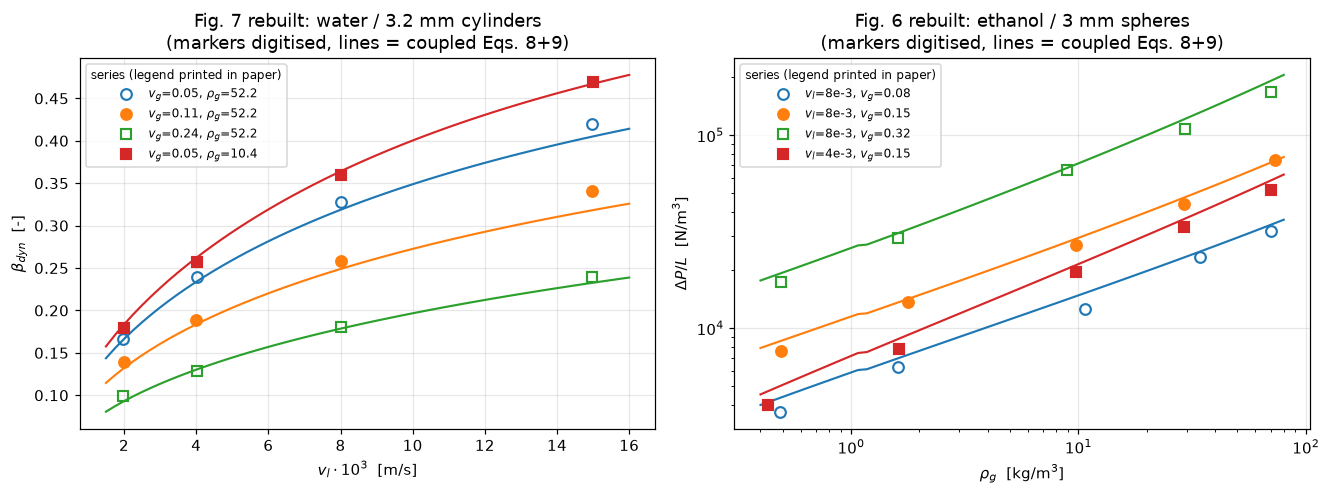

deviation, (model - measured)/measured:
  hold-up   (16 pts): mean |dev|   2.9 %   bias  -2.0 %   worst   6.8 %
  pressure  (20 pts): mean |dev|  10.4 %   bias +10.3 %   worst  21.8 %


In [6]:
MK = {"open_circle": dict(marker="o", mfc="none"), "filled_circle": dict(marker="o"),
      "open_square": dict(marker="s", mfc="none"), "filled_square": dict(marker="s")}

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))

# --- Fig. 7 rebuild ---
ax = axes[0]
vl_line = np.linspace(1.5e-3, 16e-3, 60)
for mk, g in holdup.groupby("marker", sort=False):
    vg, rho = g.v_g_m_s.iloc[0], g.rho_g_kg_m3.iloc[0]
    line = solve_pair(np.full_like(vl_line, vg), vl_line,
                      np.full_like(vl_line, rho),
                      gas_viscosity(np.full_like(vl_line, rho), "nitrogen"),
                      P["water_density"], P["water_viscosity"], EPS_C, DP_C, BR_C)
    col = f"C{list(MK).index(mk)}"
    ax.plot(vl_line * 1e3, line["beta_dyn"], "-", color=col, lw=1.4)
    ax.plot(g.v_l_m_s * 1e3, g.beta_dyn, ls="none", color=col, ms=7, mew=1.4,
            label=rf"$v_g$={vg}, $\rho_g$={rho}", **MK[mk])
ax.set(xlabel=r"$v_l \cdot 10^3$  [m/s]", ylabel=r"$\beta_{dyn}$  [-]",
       title="Fig. 7 rebuilt: water / 3.2 mm cylinders\n(markers digitised, lines = coupled Eqs. 8+9)")
ax.legend(fontsize=8, title="series (legend printed in paper)", title_fontsize=8)

# --- Fig. 6 rebuild ---
ax = axes[1]
rho_line = np.logspace(np.log10(0.4), np.log10(80), 60)
for mk, g in pgrad.groupby("marker", sort=False):
    vl, vg = g.v_l_m_s.iloc[0], g.v_g_m_s.iloc[0]
    eta_line = np.where(rho_line < 1.15, gas_viscosity(rho_line, "helium"),
                        gas_viscosity(rho_line, "nitrogen"))
    line = solve_pair(np.full_like(rho_line, vg), np.full_like(rho_line, vl),
                      rho_line, eta_line,
                      P["ethanol_density"], P["ethanol_viscosity"], EPS_S, DP_S, BR_S)
    col = f"C{list(MK).index(mk)}"
    ax.loglog(rho_line, line["dPL"], "-", color=col, lw=1.4)
    ax.loglog(g.rho_g_kg_m3, g.dP_L_N_m3, ls="none", color=col, ms=7, mew=1.4,
              label=f"$v_l$={vl*1e3:.0f}e-3, $v_g$={vg}", **MK[mk])
ax.set(xlabel=r"$\rho_g$  [kg/m$^3$]", ylabel=r"$\Delta P/L$  [N/m$^3$]",
       title="Fig. 6 rebuilt: ethanol / 3 mm spheres\n(markers digitised, lines = coupled Eqs. 8+9)")
ax.legend(fontsize=8, title="series (legend printed in paper)", title_fontsize=8)
fig.tight_layout()
plt.show()

dev7 = sol7["beta_dyn"] / holdup.beta_dyn.values - 1.0
dev6 = sol6["dPL"] / pgrad.dP_L_N_m3.values - 1.0
print("deviation, (model - measured)/measured:")
print(f"  hold-up   (16 pts): mean |dev| {np.abs(dev7).mean()*100:5.1f} %   "
      f"bias {dev7.mean()*100:+5.1f} %   worst {np.abs(dev7).max()*100:5.1f} %")
print(f"  pressure  (20 pts): mean |dev| {np.abs(dev6).mean()*100:5.1f} %   "
      f"bias {dev6.mean()*100:+5.1f} %   worst {np.abs(dev6).max()*100:5.1f} %")

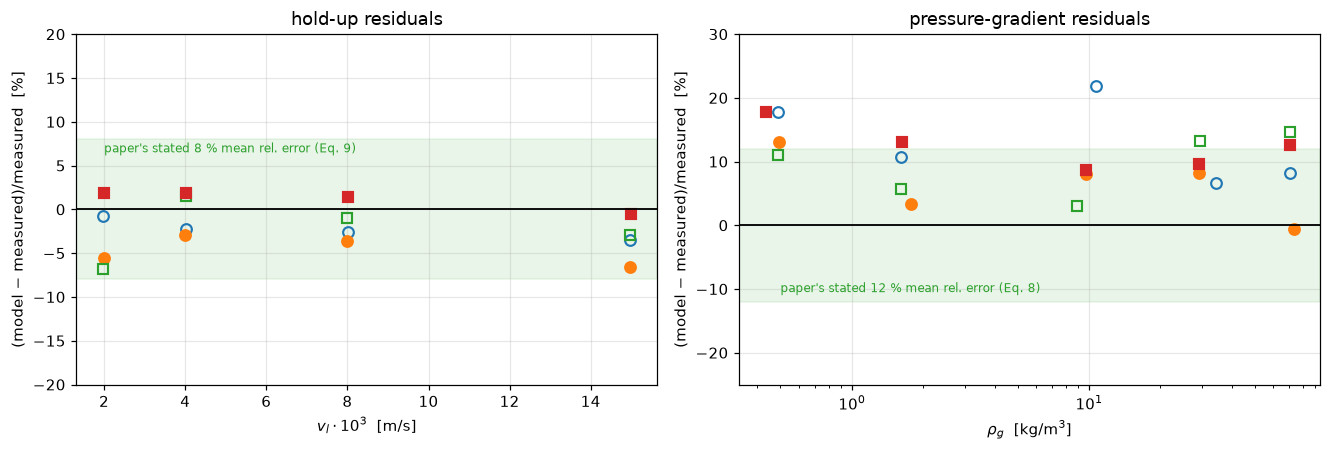

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))
ax = axes[0]
for mk, g in holdup.groupby("marker", sort=False):
    i = holdup.index.isin(g.index)
    col = f"C{list(MK).index(mk)}"
    ax.plot(g.v_l_m_s * 1e3, dev7[i] * 100, ls="none", color=col, ms=7, mew=1.4, **MK[mk])
ax.axhline(0, color="k", lw=1.2)
ax.axhspan(-8, 8, color="tab:green", alpha=0.10)
ax.text(2.0, 6.5, "paper's stated 8 % mean rel. error (Eq. 9)", fontsize=8, color="tab:green")
ax.set(xlabel=r"$v_l \cdot 10^3$  [m/s]", ylabel="(model $-$ measured)/measured  [%]",
       ylim=(-20, 20), title="hold-up residuals")

ax = axes[1]
for mk, g in pgrad.groupby("marker", sort=False):
    i = pgrad.index.isin(g.index)
    col = f"C{list(MK).index(mk)}"
    ax.semilogx(g.rho_g_kg_m3, dev6[i] * 100, ls="none", color=col, ms=7, mew=1.4, **MK[mk])
ax.axhline(0, color="k", lw=1.2)
ax.axhspan(-12, 12, color="tab:green", alpha=0.10)
ax.text(0.5, -10.5, "paper's stated 12 % mean rel. error (Eq. 8)", fontsize=8, color="tab:green")
ax.set(xlabel=r"$\rho_g$  [kg/m$^3$]", ylabel="(model $-$ measured)/measured  [%]",
       ylim=(-25, 30), title="pressure-gradient residuals")
fig.tight_layout()
plt.show()

## Validation

Seven checks, ordered from free internal identities to the data comparison.
The transcription checks matter here as much as the agreement: every constant
came off a scanned page whose OCR is unusable, so the paper is made to pay for
its own proofreading wherever it can.

In [8]:
print("1. Table 2's gas-density coefficients against the ideal gas law at 293 K")
for gas, M, printed in (("N2", 28.0134e-3, P["n2_density_per_bar"]),
                        ("He", 4.0026e-3, P["he_density_per_bar"])):
    calc = 1e5 * M / (R_GAS * 293.0)
    print(f"   {gas}: rho/P = {calc:.3f} kg/m3/bar computed, {printed} printed "
          f"({(calc/printed-1)*100:+.1f} %)")
print("   -> the transcribed coefficients are physical, and the He/N2 ratio")
print(f"      {P['n2_density_per_bar']/P['he_density_per_bar']:.2f} reproduces the paper's "
      "'M_N2/M_He = 7' argument")

print("\n2. The paper's stated He-7.0-MPa == N2-1.0-MPa equivalence")
rho_he, rho_n2 = P["he_density_per_bar"] * 70, P["n2_density_per_bar"] * 10
print(f"   rho(He, 7.0 MPa) = {rho_he:.1f} kg/m3, rho(N2, 1.0 MPa) = {rho_n2:.1f} kg/m3 "
      f"({(rho_n2/rho_he-1)*100:+.1f} %) - 'the same' within the coefficients' 2 digits")

print("\n3. The fitted-range endpoints are the operating envelope, recomputed")
ga_w = P["cylinder_dp"]**3 * P["water_density"]**2 * G / P["water_viscosity"]**2
re_max = P["water_density"] * 16e-3 * P["cylinder_dp"] / P["water_viscosity"]
print(f"   Ga_l(water, 3.2 mm) = {ga_w:.3g} vs printed cap 0.32e6 "
      f"({(ga_w/0.32e6-1)*100:+.1f} %)")
print(f"   Re_l(water, v_l max 16 mm/s) = {re_max:.1f} vs printed cap 55")
print("   -> both printed range caps are reproduced by the printed operating")
print("      conditions; the transcriptions are mutually consistent")

print("\n4. Eq. (5) + friction factor vs Eq. (8): the printed prefactor discrepancy")
b0, dPL0 = 0.25, None
vg0, rho0, eta0 = 0.11, 52.2, float(gas_viscosity(52.2, "nitrogen"))
u0 = vg0 / (EPS_C * (1 - BR_C - b0))
Re80 = rho0 * u0 * EPS_C * DP_C / (eta0 * (1 - EPS_C))
lhs = 155 * Re80**-0.37 * 0.5 * rho0 * u0**2 / DP_C * (1-EPS_C)/(EPS_C*(1-BR_C-b0))
rhs = (155 * (rho0*u0*EPS_C*DP_C/(eta0*(1-EPS_C)))**-0.37) \
      * 0.5*rho0*u0**2/DP_C * (1-EPS_C)/(EPS_C*(1-BR_C-b0))
print(f"   f_lg = 155*Re^-0.37 in Eq. (5) vs Eq. (8) direct: "
      f"|rel diff| = {abs(lhs/rhs-1):.1e}  (identity, as implemented)")
Rh = EPS_C * DP_C / (6 * (1 - EPS_C))           # hydraulic diameter eps/a_s
Reg_hydr = rho0 * u0 * Rh / eta0
factor = 155 * Re80**-0.37 / Reg_hydr**-0.37
print(f"   Eq. (7) as printed (f_lg = Re_g^-0.37 on the hydraulic diameter)")
print(f"   differs from Eq. (8)'s friction factor by {factor:.1f}x "
      f"(= 155 x 6^-0.37 = {155*6**-0.37:.1f})")
print("   -> Eq. (7) cannot be literal; Eq. (8), which carries the error")
print("      statistics and (checks 6-7) the data, is what this page implements")

1. Table 2's gas-density coefficients against the ideal gas law at 293 K
   N2: rho/P = 1.150 kg/m3/bar computed, 1.15 printed (-0.0 %)
   He: rho/P = 0.164 kg/m3/bar computed, 0.16 printed (+2.7 %)
   -> the transcribed coefficients are physical, and the He/N2 ratio
      7.19 reproduces the paper's 'M_N2/M_He = 7' argument

2. The paper's stated He-7.0-MPa == N2-1.0-MPa equivalence
   rho(He, 7.0 MPa) = 11.2 kg/m3, rho(N2, 1.0 MPa) = 11.5 kg/m3 (+2.7 %) - 'the same' within the coefficients' 2 digits

3. The fitted-range endpoints are the operating envelope, recomputed
   Ga_l(water, 3.2 mm) = 3.21e+05 vs printed cap 0.32e6 (+0.5 %)
   Re_l(water, v_l max 16 mm/s) = 51.2 vs printed cap 55
   -> both printed range caps are reproduced by the printed operating
      conditions; the transcriptions are mutually consistent

4. Eq. (5) + friction factor vs Eq. (8): the printed prefactor discrepancy
   f_lg = 155*Re^-0.37 in Eq. (5) vs Eq. (8) direct: |rel diff| = 0.0e+00  (identity, as imple

In [9]:
print("5. The pymrm S3 solve against the paper's own closed form, Eq. (3)")
errs = []
for n in (50, 100, 200, 400, 800):
    _, _, xi_n = co2_plugflow(a_gl_demo, K_DEA, L_ABS, VG_ABS, n=n)
    errs.append(abs(xi_n - xi_exact))
    print(f"   n = {n:4d}: xi = {xi_n:.6f}   |xi - exact| = {errs[-1]:.2e}")
orders = np.log2(np.array(errs[:-1]) / np.array(errs[1:]))
print(f"   observed order: {orders.mean():.2f} (first-order upwind on pure convection)")
a_800 = -VG_ABS / (K_DEA * L_ABS) * np.log(1.0 - (xi_exact - errs[-1]))
print(f"   Eq. (3) round trip at n = 800: a_gl in {a_gl_demo:.1f} -> "
      f"{a_800:.1f} m2/m3 ({(a_800/a_gl_demo-1)*100:+.3f} %); the residual is")
print("   exactly the discretisation error - Eqs. (2) and (3) are the same")
print("   statement, so the round trip is an identity check on both")

5. The pymrm S3 solve against the paper's own closed form, Eq. (3)
   n =   50: xi = 0.654398   |xi - exact| = 4.72e-03
   n =  100: xi = 0.656750   |xi - exact| = 2.37e-03
   n =  200: xi = 0.657934   |xi - exact| = 1.19e-03
   n =  400: xi = 0.658527   |xi - exact| = 5.95e-04
   n =  800: xi = 0.658825   |xi - exact| = 2.98e-04
   observed order: 1.00 (first-order upwind on pure convection)
   Eq. (3) round trip at n = 800: a_gl in 534.4 -> 533.9 m2/m3 (-0.081 %); the residual is
   exactly the discretisation error - Eqs. (2) and (3) are the same
   statement, so the round trip is an identity check on both


In [10]:
print("6. Hold-up: coupled pair vs the 16 digitised Fig. 7 points")
print(f"   mean |dev| {np.abs(dev7).mean()*100:.1f} %, bias {dev7.mean()*100:+.1f} %, "
      f"worst {np.abs(dev7).max()*100:.1f} %")
print(f"   paper's own statistics for Eq. (9) over all 220 runs: "
      f"mean rel. error {P['eq9_mean_rel_error']*100:.0f} %, std {P['eq9_error_std']}")
print("   -> comfortably inside. The range check, counted rather than asserted:")
ok_re = (sol7["Re_l"] >= P["Re_l_min"]) & (sol7["Re_l"] <= P["Re_l_max"])
ok_dp = sol7["dP_grav"] <= P["dP_rho_gL_max"]
ok_bt = sol7["beta_t"] > P["beta_t_min"]
ga7 = DP_C**3 * P["water_density"]**2 * G / P["water_viscosity"]**2
print(f"      Re_l in [2,55]: {ok_re.sum()}/16;  dP/rho_l gL <= 16: {ok_dp.sum()}/16;  "
      f"beta_t > 0.25: {ok_bt.sum()}/16")
if ok_bt.sum() < 16:
    print(f"      -> {16-ok_bt.sum()} of the 16 sit just below Eq. (8)'s beta_t > 0.25 floor "
          f"(min {sol7['beta_t'].min():.3f}); a")
    print("         mild extrapolation, flagged rather than hidden - the paper says")
    print("         Eq. (8) underestimates there, approaching the Ergun limits")
print(f"      Ga_l = {ga7:.4g}: this system IS the printed range cap 0.32e6 "
      f"({(ga7/0.32e6-1)*100:+.1f} % - check 3)")
reg_out7 = ((sol7["Re_g"] < P["Re_g_min"]) | (sol7["Re_g"] > P["Re_g_max"])).sum()
print(f"      Re_g in [200,5000]: {16-reg_out7}/16 (the v_g = 0.24 m/s series sits at "
      f"Re_g {sol7['Re_g'][8:12].min():.0f}-{sol7['Re_g'][8:12].max():.0f}, just above Eq. 8's "
      "fitted cap;")
print("      the paper itself notes f_lg tends to Re^-0.25 there, a mild extrapolation -")
print("      and that series' deviations, -7 to +1 %, do not stand out)")

print("\n7. Pressure gradient: coupled pair vs the 20 digitised Fig. 6 points")
inr = (sol6["Re_g"] >= P["Re_g_min"]) & (sol6["Re_g"] <= P["Re_g_max"])
print(f"   all 20 points:      mean |dev| {np.abs(dev6).mean()*100:.1f} %, "
      f"bias {dev6.mean()*100:+.1f} %")
print(f"   Re_g in [200,5000] ({inr.sum()} pts): mean |dev| "
      f"{np.abs(dev6[inr]).mean()*100:.1f} %, bias {dev6[inr].mean()*100:+.1f} %")
n_hi = (sol6["dP_grav"] > P["dP_rho_gL_max"]).sum()
print(f"   note: {n_hi} high-density point{'s' if n_hi != 1 else ''} sit{'' if n_hi != 1 else 's'} above Eq. 9's fitted "
      f"dP/rho_l gL <= 16 (max {sol6['dP_grav'].max():.1f}) - there the co-predicted")
print("   hold-up is an extrapolation, exactly as the paper warns near pulse flow")
print(f"   paper's own statistics for Eq. (8): mean rel. error "
      f"{P['eq8_mean_rel_error']*100:.0f} %, std {P['eq8_error_std']}")
print("   -> inside the stated error, but with a systematic +10 % bias; the")
print("      candidates are the unprinted tall-bed porosity, d_p = 3 +/- 0.5 mm,")
print("      and the gas-identity ambiguity:")
def pgrad_bias(eps_try):
    s = solve_pair(pgrad.v_g_m_s.values, pgrad.v_l_m_s.values,
                   pgrad.rho_g_kg_m3.values, eta6,
                   P["ethanol_density"], P["ethanol_viscosity"], eps_try, DP_S,
                   P["eps_beta_residual"] / eps_try)
    return float((s["dPL"] / pgrad.dP_L_N_m3.values - 1.0).mean())


for eps_try in (0.37, 0.39, 0.41):
    print(f"      eps = {eps_try:.2f}: bias {pgrad_bias(eps_try)*100:+5.1f} %   "
          f"(dP/L ~ eps^-2.6 at fixed beta_t: strong)")
eps_zero = brentq(pgrad_bias, 0.38, 0.42, xtol=1e-6)
print(f"      the bias vanishes at eps = {eps_zero:.4f}, i.e. "
      f"{eps_zero - EPS_S:+.4f} on the printed {EPS_S}")
print("      -> under +0.01 in porosity, well inside packing-to-packing scatter,")
print("         accounts for the whole bias. Note +0.02 OVERSHOOTS it, to")
print(f"         {pgrad_bias(EPS_S + 0.02)*100:+.1f} %: this is a sensitivity, not a fit, and the")
print("         page keeps the printed 0.39 rather than tuning to the data")

# the third named candidate, measured rather than asserted: flip every
# gas-ambiguous Fig. 6 point to the other gas and see what moves.
amb = pgrad.assumed_gas.values == "ambiguous"
eta_alt = np.where(amb & (eta6 == gas_viscosity(pgrad.rho_g_kg_m3.values, "nitrogen")),
                   gas_viscosity(pgrad.rho_g_kg_m3.values, "helium"),
                   np.where(amb, gas_viscosity(pgrad.rho_g_kg_m3.values, "nitrogen"), eta6))
s_alt = solve_pair(pgrad.v_g_m_s.values, pgrad.v_l_m_s.values,
                   pgrad.rho_g_kg_m3.values, eta_alt,
                   P["ethanol_density"], P["ethanol_viscosity"], EPS_S, DP_S, BR_S)
d_alt = s_alt["dPL"] / pgrad.dP_L_N_m3.values - 1.0
print(f"      gas identity: {amb.sum()} of 20 points are density-ambiguous. Their He/N2")
print(f"      viscosity ratio reaches "
      f"{(gas_viscosity(pgrad.rho_g_kg_m3.values[amb],'helium')/gas_viscosity(pgrad.rho_g_kg_m3.values[amb],'nitrogen')).max():.3f}, "
      "but it enters as Re_g^-0.37, so flipping all")
print(f"      {amb.sum()} to the other gas moves dP/L by at most "
      f"{np.abs(s_alt['dPL'][amb]/sol6['dPL'][amb] - 1).max()*100:.1f} % and the overall bias from")
print(f"      {dev6.mean()*100:+.1f} % to {d_alt.mean()*100:+.1f} %. It is the smallest of the three candidates,")
print("      and it cannot explain the bias - it points the wrong way.")

6. Hold-up: coupled pair vs the 16 digitised Fig. 7 points
   mean |dev| 2.9 %, bias -2.0 %, worst 6.8 %
   paper's own statistics for Eq. (9) over all 220 runs: mean rel. error 8 %, std 0.1
   -> comfortably inside. The range check, counted rather than asserted:
      Re_l in [2,55]: 16/16;  dP/rho_l gL <= 16: 16/16;  beta_t > 0.25: 15/16
      -> 1 of the 16 sit just below Eq. (8)'s beta_t > 0.25 floor (min 0.232); a
         mild extrapolation, flagged rather than hidden - the paper says
         Eq. (8) underestimates there, approaching the Ergun limits
      Ga_l = 3.215e+05: this system IS the printed range cap 0.32e6 (+0.5 % - check 3)
      Re_g in [200,5000]: 12/16 (the v_g = 0.24 m/s series sits at Re_g 5118-6258, just above Eq. 8's fitted cap;
      the paper itself notes f_lg tends to Re^-0.25 there, a mild extrapolation -
      and that series' deviations, -7 to +1 %, do not stand out)

7. Pressure gradient: coupled pair vs the 20 digitised Fig. 6 points
   all 20 points: 

### The gas-density claim, tested on a properly matched pair

Fig. 7 contains one clean group comparison: the open-circle and filled-square
series share $v_g = 0.05$ m/s and the same four nominal $v_l$ settings, and
differ only in gas density (52.2 vs 10.4 kg/m³). Unlike the `F1.4` SF₆ test,
the groups overlap in every other variable, so the measured ratio is the gas
effect — no confound. The digitised abscissae are not bit-identical between the
two series, because each was read off the figure separately; the cell below
prints how far apart they are and what that is worth, so the pairing is
measured rather than asserted.

The model says the entire effect routes through $\Delta P$ in Eq. (9) — that
much is structural, since $\rho_g$ appears nowhere else in Eq. (9) — so the
test is whether the *size* of the shift comes out right: at higher $\rho_g$ the
pressure gradient grows, the modified Galileo number grows, and the hold-up
falls. This one can fail, and it partly does: the direction and order of
magnitude are right, the magnitude is overpredicted. The numbers are below.

In [11]:
oc = holdup[holdup.marker == "open_circle"].sort_values("v_l_m_s")
fs = holdup[holdup.marker == "filled_square"].sort_values("v_l_m_s")
r_meas = fs.beta_dyn.values / oc.beta_dyn.values
i_oc = holdup.index.isin(oc.index)
i_fs = holdup.index.isin(fs.index)
r_model = sol7["beta_dyn"][i_fs] / sol7["beta_dyn"][i_oc]
vl_mismatch = np.abs(fs.v_l_m_s.values / oc.v_l_m_s.values - 1.0)
print(f"how well matched the two series are in v_l: worst mismatch "
      f"{vl_mismatch.max()*100:.1f} % (digitisation, not design)")
print(f"   beta_dyn ~ Re_l^0.55, so that is worth "
      f"{((1+vl_mismatch.max())**0.55 - 1)*100:.1f} % on the ratio - an order of")
print("   magnitude smaller than the effect being measured, so the pairing holds")
print("\nbeta_dyn(rho_g=10.4) / beta_dyn(rho_g=52.2), matched v_g = 0.05 m/s:")
print(f"   {'v_l [mm/s]':>12} {'measured':>10} {'model':>8}")
for vl, rm, rp in zip(oc.v_l_m_s * 1e3, r_meas, r_model):
    print(f"   {vl:12.1f} {rm:10.3f} {rp:8.3f}")
print(f"   mean measured ratio {r_meas.mean():.3f}, mean model ratio {r_model.mean():.3f}")
print(f"   -> a 5x density change moves the measured hold-up by "
      f"{(r_meas.mean()-1)*100:.1f} %; routing that")
print(f"      through the pressure gradient alone, as Eq. (9) does, predicts "
      f"{(r_model.mean()-1)*100:.1f} %.")
print(f"      The mechanism is confirmed in sign and order of magnitude and")
print(f"      OVERPREDICTED in size by a factor "
      f"{(r_model.mean()-1)/(r_meas.mean()-1):.1f}. The check can fail and it")
print(f"      partly does: {(r_model.mean()/r_meas.mean()-1)*100:+.1f} % on the ratio itself, which is")
print("      inside the +/-8 % Eq. (9) carries, so this sharpens the paper's")
print("      claim without contradicting it.")

print("\nbonus check: the a_s convention in Eq. (9)")
alt = (6.0 / EPS_C) / (6.0 * (1 - EPS_C) / EPS_C)   # per-solid-volume reading
print(f"   reading a_s per particle volume would multiply every prediction by "
      f"{alt**0.65:.2f}x;")
print(f"   the observed bias is {dev7.mean()*100:+.1f} % - the per-bed-volume reading "
      "is the paper's")

report_agreement("G1.7", {
    "holdup_mean_abs_dev": float(np.abs(dev7).mean()),
    "holdup_bias": float(dev7.mean()),
    "holdup_worst_abs_dev": float(np.abs(dev7).max()),
    "pgrad_mean_abs_dev": float(np.abs(dev6).mean()),
    "pgrad_bias": float(dev6.mean()),
    "pgrad_inrange_mean_abs_dev": float(np.abs(dev6[inr]).mean()),
    "gas_density_ratio_meas": float(r_meas.mean()),
    "gas_density_ratio_model": float(r_model.mean()),
    "xi_upwind_err_n200": float(errs[2]),
    "table2_n2_density_relerr": float(1e5 * 28.0134e-3 / (R_GAS * 293.0)
                                      / P["n2_density_per_bar"] - 1.0),
})

how well matched the two series are in v_l: worst mismatch 1.0 % (digitisation, not design)
   beta_dyn ~ Re_l^0.55, so that is worth 0.6 % on the ratio - an order of
   magnitude smaller than the effect being measured, so the pairing holds

beta_dyn(rho_g=10.4) / beta_dyn(rho_g=52.2), matched v_g = 0.05 m/s:
     v_l [mm/s]   measured    model
            2.0      1.080    1.108
            4.0      1.075    1.121
            8.0      1.096    1.142
           15.0      1.119    1.153
   mean measured ratio 1.092, mean model ratio 1.131
   -> a 5x density change moves the measured hold-up by 9.2 %; routing that
      through the pressure gradient alone, as Eq. (9) does, predicts 13.1 %.
      The mechanism is confirmed in sign and order of magnitude and
      OVERPREDICTED in size by a factor 1.4. The check can fail and it
      partly does: +3.5 % on the ratio itself, which is
      inside the +/-8 % Eq. (9) carries, so this sharpens the paper's
      claim without contradicting it.


{'page': 'G1.7',
 'metrics': {'holdup_mean_abs_dev': 0.028562099798442535,
  'holdup_bias': -0.02015951805402371,
  'holdup_worst_abs_dev': 0.06817729574708109,
  'pgrad_mean_abs_dev': 0.10382952368723761,
  'pgrad_bias': 0.10318721216388585,
  'pgrad_inrange_mean_abs_dev': 0.08862746831257194,
  'gas_density_ratio_meas': 1.0924479041267081,
  'gas_density_ratio_model': 1.1310243676863783,
  'xi_upwind_err_n200': 0.0011883967443268029,
  'table2_n2_density_relerr': -2.2238862301016127e-05}}

## What pymrm adds

**To the correlations, honestly: a closure the paper states but never shows.**
Eqs. (8) and (9) are printed as separate correlations with a sentence saying
they "can be" combined. This page combines them — 36 operating points solved
simultaneously with `NumJac` + `newton` — and shows the pair closes to 2.9 %
on the hold-up figure and ~10 % on the pressure-gradient figure with nothing
fitted. That the *coupled* system, not each correlation fed measured inputs,
reproduces both figures is a statement the paper never quite makes.

**The S3 model is where the operators earn their place.** The plug-flow CO₂
balance behind every interfacial-area measurement in the paper is a 1D steady
convection–sink equation; pymrm discretises it with the same
`construct_convflux_upwind` + `construct_div` + outward-normal `bc` pattern
every reactor page uses, and the paper's own Eq. (3) provides the exact
solution that measures the discretisation error (first order, as upwind must
be). Swap the linear sink for the real DEA kinetics with liquid-side balances
and this skeleton becomes a working high-pressure absorber model — that is the
reuse path.

**And a sharpened version of the paper's argument.** "Density, not pressure"
is demonstrated in the paper by overlaying transition lines. Here it becomes a
matched-pair number, and a number can disagree: a 5× density change moves the
measured hold-up by 9.2 %, while routing the whole effect through the pressure
gradient — which is what Eq. (9) does, $\rho_g$ appearing nowhere else in it —
predicts 13.1 %. The mechanism is right in sign and order of magnitude and
overpredicted in size by a factor of 1.4. That is a 3.5 % discrepancy on the ratio
itself, inside the 8 % Eq. (9) carries, so it sharpens the paper's claim rather
than contradicting it — but it is evidence that the pressure gradient is not
quite the *whole* of the density effect, and the page reports it as such.

## Reuse

**The closure is standalone.** `solve_pair` takes
$(v_g, v_l, \rho_g, \eta_g)$, liquid properties, $(\varepsilon, d_p, \beta_r)$
in SI and returns hold-up, pressure gradient, and the dimensionless groups for
range checking. Use it as the hydrodynamic closure of any trickle-bed reactor
model — `G1.8` (partial wetting, this paper's sibling case) is the natural
consumer, and a high-pressure hydrogenation model needs exactly this pair.

**Ranges, from the paper.** $\beta_t > 0.25$ and $200 < Re_g < 5000$ for the
pressure gradient (below $\beta_t = 0.25$ it *underestimates*, approaching the
Ergun limits); $2 \le Re_l \le 55$, $3.2{\times}10^3 \le Ga_l \le
0.32{\times}10^6$, $\Delta P/\rho_l g L \le 16$ for the hold-up. Trickle-flow
regime only: past the pulse transition the hold-up is overestimated and the
pressure drop underestimated (the paper says so). Non-foaming liquids; the
correlations carry no surface-tension term because none was observed on the
dynamic hold-up.

**Residual hold-up:** $\varepsilon\beta_r = 0.06$ for well-wetted packings (Van
Swaaij's Eötvös relation); poorly wetted surfaces can halve it — the paper's
antifoam-contaminated glass gave 0.03.

**Convention traps.** $\beta$ values are per unit **void** volume (multiply by
$\varepsilon$ for per-bed); $a_s$ in Eq. (9) is per unit **bed** volume;
$u_g$ in Eq. (8) is the **interstitial** velocity of Eq. (6), which itself
contains $\beta_t$ — forgetting that inner dependence breaks the coupling.

**Related pages.** `G1.8` (trickle-bed reactor consuming this closure),
[`F1.4`](../F1.4-krishna-ellenberger-holdup/) (the template for testing a
correlation on its own figure), [`F2.3`](../F2.3-slurry-bubble-column-ft/)
(multiphase column with hydrodynamic closures), `F3.1` (the fast-reaction
absorption regime behind Eq. 1).

**Cite the source, not this page:** Wammes, W. J. A. and Westerterp, K. R.,
*Hydrodynamics in a pressurized cocurrent gas–liquid trickle-bed reactor*,
Chemical Engineering & Technology **14**(6) 406–413 (1991),
[doi:10.1002/ceat.270140608](https://doi.org/10.1002/ceat.270140608). The
catalogue's original citation, Chem. Eng. Sci. 46 (1991) 409–417 (Wammes,
Mechielsen & Westerterp), is the atmospheric companion study.